<a href="https://colab.research.google.com/github/TAMIDSpiyalong/Advanced-Concepts-in-Machine-Learning-for-Energy/blob/main/Lecture_4c_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi-Head Self-Attention

In [10]:
import tensorflow_datasets as tfds
import tensorflow as tf

import time
import numpy as np


Inside each attention head is a **Scaled Dot Product Self-Attention** operation as we covered in the slides. Given *queries*, *keys*, and *values*, the operation returns a new "mix" of the values.

$$Attention(Q, K, V) = softmax(\frac{QK^T)}{\sqrt{d_k}})V$$

The following function implements this and also takes a mask to account for padding and for masking future tokens for decoding (i.e. **look-ahead mask**). We'll cover masking later in the notebook.

In [11]:
def scaled_dot_product_attention(q, k, v, mask=None):
  """Calculate the attention weights.
  q, k, v must have matching leading dimensions.
  k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
  The mask has different shapes depending on its type(padding or look ahead)
  but it must be broadcastable for addition.

  Args:
    q: query shape == (..., seq_len_q, depth)
    k: key shape == (..., seq_len_k, depth)
    v: value shape == (..., seq_len_v, depth_v)
    mask: Float tensor with shape broadcastable
          to (..., seq_len_q, seq_len_k). Defaults to None.

  Returns:
    output, attention_weights
  """

  matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

  # scale matmul_qk
  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  # add the mask to the scaled tensor.
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)

  # softmax is normalized on the last axis (seq_len_k) so that the scores
  # add up to 1.
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

  output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

  return output, attention_weights

Suppose our *queries*, *keys*, and *values* are each a length of 3 with a dimension of 4.

In [12]:
seq_len = 3
embed_dim = 4

queries = np.random.rand(seq_len, embed_dim).astype('float32')
keys = np.random.rand(seq_len, embed_dim).astype('float32')
values = np.random.rand(seq_len, embed_dim).astype('float32')

print("Queries:\n", queries)

Queries:
 [[0.7969249  0.10289853 0.308665   0.5628114 ]
 [0.90254426 0.55285954 0.36588925 0.28955704]
 [0.3547093  0.5887625  0.82602364 0.5211892 ]]


This would be the self-attention output and weights.

In [13]:
output, attn_weights = scaled_dot_product_attention(queries, keys, values)

print("Output\n", output, "\n")
print("Weights\n", attn_weights)

Output
 tf.Tensor(
[[0.60792094 0.33492222 0.5530641  0.5272514 ]
 [0.60790485 0.3332092  0.5557989  0.5240451 ]
 [0.61415017 0.3162408  0.58446026 0.47406012]], shape=(3, 4), dtype=float32) 

Weights
 tf.Tensor(
[[0.36837393 0.31223345 0.31939262]
 [0.3642502  0.31700063 0.3187492 ]
 [0.32302856 0.38542894 0.2915425 ]], shape=(3, 3), dtype=float32)


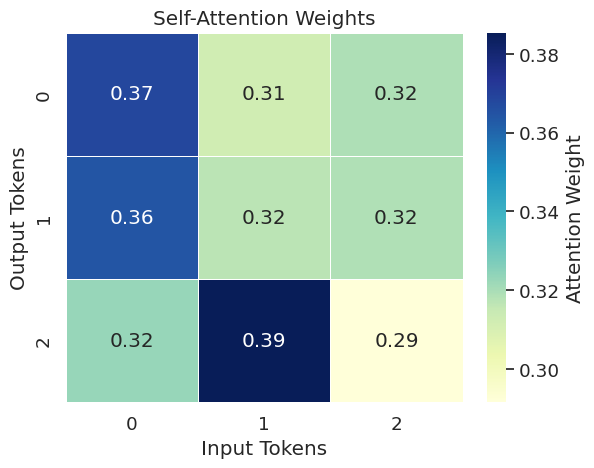

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
def visualize_attention(attention_weights):
    # Create heatmap using seaborn
    sns.set(font_scale=1.2)
    plt.figure()
    ax = sns.heatmap(
        attention_weights,
        cmap="YlGnBu",
        linewidths=0.5,
        annot=True,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'Attention Weight'}
    )
    ax.set_title('Self-Attention Weights')
    plt.xlabel('Input Tokens')
    plt.ylabel('Output Tokens')
    plt.show()


visualize_attention(attn_weights)


Now that we have a way to calculate self-attention, let's actually generate the input *queries*, *keys*, and *values* for multiple heads. It's easier to understand things this way and we can certainly code it this way as well. But we can also "simulate" different heads with a single query matrix, single key matrix, and single value matrix.

In [15]:
batch_size = 1
seq_len = 3
embed_dim = 12
num_heads = 3
head_dim = embed_dim // num_heads

print(f"Dimension of each head: {head_dim}")

Dimension of each head: 4


**Using separate weight matrices per head**

Suppose these are our input embeddings. Here we have a batch of 1 containing a sequence of length 3, with each element being a 12-dimensional embedding.

In [16]:
x = np.random.rand(batch_size, seq_len, embed_dim).round(1).astype('float32')
print("Input shape: ", x.shape, "\n")
print("Input:\n", x)

Input shape:  (1, 3, 12) 

Input:
 [[[0.7 0.2 0.2 0.5 0.4 0.3 0.4 0.5 0.4 0.8 0.6 0.5]
  [0.  0.7 0.9 0.2 0.6 0.1 0.2 0.6 0.6 0.8 0.6 0.4]
  [0.1 0.  0.2 0.5 0.7 0.1 0.1 0.1 0.5 0.3 0.4 0.9]]]


We'll declare three sets of *query* weights (one for each head), three sets of *key* weights, and three sets of *value* weights. Remember each weight matrix should have a dimension of $\text{d}\ \text{x}\ \text{d/h}$.

In [17]:
# The query weights for each head.
wq0 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wq1 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wq2 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')

# The key weights for each head.
wk0 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wk1 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wk2 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')

# The value weights for each head.
wv0 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wv1 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')
wv2 = np.random.rand(embed_dim, head_dim).round(1).astype('float32')

In [18]:
print("The three sets of query weights (one for each head):")
print("wq0:\n", wq0)
print("wq1:\n", wq1)
print("wq2:\n", wq1)

The three sets of query weights (one for each head):
wq0:
 [[0.2 0.5 0.6 0.8]
 [0.6 0.2 0.1 0.6]
 [0.5 0.7 0.6 0.9]
 [0.4 0.9 0.6 0.4]
 [0.2 0.4 0.7 0.9]
 [0.9 0.4 0.3 0.5]
 [0.5 0.5 0.9 0.8]
 [0.1 0.8 0.8 0.7]
 [0.5 0.4 0.2 0.1]
 [0.8 0.8 0.7 0.7]
 [0.  1.  0.9 0.5]
 [0.8 0.8 0.3 0.3]]
wq1:
 [[0.3 0.2 1.  0.1]
 [0.8 0.  0.4 0.3]
 [0.6 0.5 0.6 0.7]
 [0.2 0.3 0.9 0.3]
 [0.3 0.6 0.3 0.3]
 [0.1 0.7 1.  0.9]
 [0.2 0.8 0.5 0.5]
 [0.8 0.7 0.1 0.6]
 [0.4 0.5 0.4 0.5]
 [0.2 0.7 0.3 0.7]
 [0.3 0.1 0.9 0.2]
 [0.9 0.8 0.3 0.3]]
wq2:
 [[0.3 0.2 1.  0.1]
 [0.8 0.  0.4 0.3]
 [0.6 0.5 0.6 0.7]
 [0.2 0.3 0.9 0.3]
 [0.3 0.6 0.3 0.3]
 [0.1 0.7 1.  0.9]
 [0.2 0.8 0.5 0.5]
 [0.8 0.7 0.1 0.6]
 [0.4 0.5 0.4 0.5]
 [0.2 0.7 0.3 0.7]
 [0.3 0.1 0.9 0.2]
 [0.9 0.8 0.3 0.3]]


We'll generate our *queries*, *keys*, and *values* for each head by multiplying our input by the weights.

In [19]:
# Geneated queries, keys, and values for the first head.
q0 = np.dot(x, wq0)
k0 = np.dot(x, wk0)
v0 = np.dot(x, wv0)

# Geneated queries, keys, and values for the second head.
q1 = np.dot(x, wq1)
k1 = np.dot(x, wk1)
v1 = np.dot(x, wv1)

# Geneated queries, keys, and values for the third head.
q2 = np.dot(x, wq2)
k2 = np.dot(x, wk2)
v2 = np.dot(x, wv2)

These are the resulting *query*, *key*, and *value* vectors for the first head.

In [20]:
print("Q, K, and V for first head:\n")

print(f"q0 {q0.shape}:\n", q0, "\n")
print(f"k0 {k0.shape}:\n", k0, "\n")
print(f"v0 {v0.shape}:\n", v0)

Q, K, and V for first head:

q0 (1, 3, 4):
 [[[2.4       3.66      3.32      3.29     ]
  [2.5800002 3.6100001 3.18      3.52     ]
  [1.8199999 2.65      2.11      2.02     ]]] 

k0 (1, 3, 4):
 [[[3.0900002 2.4       2.49      3.28     ]
  [3.2600002 1.9900001 2.64      3.7      ]
  [2.05      1.45      1.39      2.43     ]]] 

v0 (1, 3, 4):
 [[[3.        1.89      2.5700002 2.7900002]
  [3.21      1.44      2.8400002 3.19     ]
  [2.21      1.12      1.59      1.95     ]]]


Now that we have our Q, K, V vectors, we can just pass them to our self-attention operation. Here we're calculating the output and attention weights for the first head.

In [21]:
out0, attn_weights0 = scaled_dot_product_attention(q0, k0, v0)

print("Output from first attention head: ", out0, "\n")
print("Attention weights from first head: ", attn_weights0)

Output from first attention head:  tf.Tensor(
[[[3.1246617 1.6208779 2.7303083 3.027988 ]
  [3.1279283 1.614118  2.7345047 3.0341454]
  [3.1092029 1.6398174 2.7106385 3.002372 ]]], shape=(1, 3, 4), dtype=float32) 

Attention weights from first head:  tf.Tensor(
[[[0.4025253  0.5966666  0.00080816]
  [0.38743433 0.61185515 0.00071049]
  [0.4487094  0.5447225  0.0065681 ]]], shape=(1, 3, 3), dtype=float32)


Here are the other two (attention weights are ignored).

In [22]:
out1, _ = scaled_dot_product_attention(q1, k1, v1)
out2, _ = scaled_dot_product_attention(q2, k2, v2)

print("Output from second attention head: ", out1, "\n")
print("Output from third attention head: ", out2,)

Output from second attention head:  tf.Tensor(
[[[2.5812378 2.3267028 3.1832862 2.5712235]
  [2.5832095 2.3250816 3.180469  2.5657656]
  [2.575562  2.3248887 3.175444  2.5736206]]], shape=(1, 3, 4), dtype=float32) 

Output from third attention head:  tf.Tensor(
[[[2.0530767 2.3387892 2.4471452 3.62907  ]
  [2.0535338 2.3393013 2.446349  3.6270483]
  [2.0562882 2.3425286 2.4352782 3.6023884]]], shape=(1, 3, 4), dtype=float32)


As we covered in the slides, once we have each head's output, we concatenate them and then put them through a linear layer for further processing.

In [23]:
combined_out_a = np.concatenate((out0, out1, out2), axis=-1)
print(f"Combined output from all heads {combined_out_a.shape}:")
print(combined_out_a)

# The final step would be to run combined_out_a through a linear/dense layer
# for further processing.

Combined output from all heads (1, 3, 12):
[[[3.1246617 1.6208779 2.7303083 3.027988  2.5812378 2.3267028 3.1832862
   2.5712235 2.0530767 2.3387892 2.4471452 3.62907  ]
  [3.1279283 1.614118  2.7345047 3.0341454 2.5832095 2.3250816 3.180469
   2.5657656 2.0535338 2.3393013 2.446349  3.6270483]
  [3.1092029 1.6398174 2.7106385 3.002372  2.575562  2.3248887 3.175444
   2.5736206 2.0562882 2.3425286 2.4352782 3.6023884]]]


Each multi-head attention block gets three inputs; Q (query), K (key), V (value). These are put through linear (Dense) layers and split up into multiple heads.

The `scaled_dot_product_attention` defined above is applied to each head (broadcasted for efficiency). An appropriate mask must be used in the attention step.  The attention output for each head is then concatenated (using `tf.transpose`, and `tf.reshape`) and put through a final `Dense` layer.

Instead of one single attention head, Q, K, and V are split into multiple heads because it allows the model to jointly attend to information at different positions from different representational spaces. After the split each head has a reduced dimensionality, so the total computation cost is the same as a single head attention with full dimensionality.

In [24]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)

    self.dense = tf.keras.layers.Dense(d_model)

  def split_heads(self, x, batch_size):
    """Split the last dimension into (num_heads, depth).
    Transpose the result such that the shape is (batch_size, num_heads, seq_len, depth)
    """
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]

    q = self.wq(q)  # (batch_size, seq_len, d_model)
    k = self.wk(k)  # (batch_size, seq_len, d_model)
    v = self.wv(v)  # (batch_size, seq_len, d_model)

    q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
    k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
    v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

    # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
    # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
    scaled_attention, attention_weights = scaled_dot_product_attention(
        q, k, v, mask)

    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

    output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

    return output, attention_weights

Create a `MultiHeadAttention` layer to try out. At each location in the sequence, `y`, the `MultiHeadAttention` runs all 8 attention heads across all other locations in the sequence, returning a new vector of the same length at each location.

In [25]:
temp_mha = MultiHeadAttention(d_model=4, num_heads=2)
y = tf.random.uniform((2, 3, 4))  # (batch_size, encoder_sequence, d_model)
out, attn = temp_mha(v=y, k=y, q=y, mask=None)
out.shape, attn.shape

(TensorShape([2, 3, 4]), TensorShape([2, 2, 3, 3]))

In [26]:
attn[0][0]

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0.3291036 , 0.3546529 , 0.3162435 ],
       [0.32354116, 0.37021893, 0.30623984],
       [0.32606444, 0.34896153, 0.32497406]], dtype=float32)>

## Positional encoding

Since this model doesn't contain any recurrence or convolution, positional encoding is added to give the model some information about the relative position of the words in the sentence.

The positional encoding vector is added to the embedding vector. Embeddings represent a token in a d-dimensional space where tokens with similar meaning will be closer to each other. But the embeddings do not encode the relative position of words in a sentence. So after adding the positional encoding, words will be closer to each other based on the *similarity of their meaning and their position in the sentence*, in the d-dimensional space.

The formula for calculating the positional encoding is as follows:

$$\Large{PE_{(pos, 2i)} = sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = cos(pos / 10000^{2i / d_{model}})} $$

In [27]:
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
  return pos * angle_rates

In [28]:
def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)

  # apply sin to even indices in the array; 2i
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

  # apply cos to odd indices in the array; 2i+1
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

  pos_encoding = angle_rads[np.newaxis, ...]

  return tf.cast(pos_encoding, dtype=tf.float32)

(1, 10, 512)


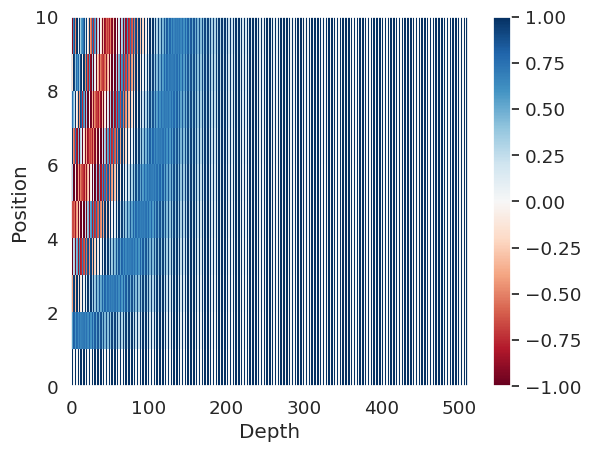

In [29]:
pos_encoding = positional_encoding(10, 512)
print (pos_encoding.shape)

plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## Masking

Mask all the pad tokens in the batch of sequence. It ensures that the model does not treat padding as the input. The mask indicates where pad value `0` is present: it outputs a `1` at those locations, and a `0` otherwise.

In [30]:
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)

  # add extra dimensions to add the padding
  # to the attention logits.
  return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

In [31]:
x = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0], [0, 0, 0, 4, 5]])
create_padding_mask(x)

<tf.Tensor: shape=(3, 1, 1, 5), dtype=float32, numpy=
array([[[[0., 0., 1., 1., 0.]]],


       [[[0., 0., 0., 1., 1.]]],


       [[[1., 1., 1., 0., 0.]]]], dtype=float32)>

The look-ahead mask is used to mask the future tokens in a sequence. In other words, the mask indicates which entries should not be used.

This means that to predict the third word, only the first and second word will be used. Similarly to predict the fourth word, only the first, second and the third word will be used and so on.

In [32]:
def create_look_ahead_mask(size):
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
  return mask  # (seq_len, seq_len)

In [33]:
x = tf.random.uniform((3, 3))
temp = create_look_ahead_mask(x.shape[1])
temp

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]], dtype=float32)>